# Μείωση Λεπτομέρειας Χάρτη Ζωνών Παράδοσης για Ταχείς Πίνακες Ελέγχου Εφοδιαστικής με την PROC GREDUCE

## Περίληψη

Μια περιφερειακή εταιρεία διανομής δεμάτων αποθηκεύει τα όρια της περιοχής εξυπηρέτησής της ως πυκνά περιγράμματα πολυγώνων, και οι πίνακες ελέγχου σχεδιασμού διαδρομών τα σχεδιάζουν αργά. Αυτό το notebook συνθέτει τις συντεταγμένες ορίων για τέσσερις ζώνες παράδοσης, χρησιμοποιεί την **PROC GREDUCE** για να επισημάνει κάθε κορυφή ορίου με ένα επίπεδο `DENSITY`, και στη συνέχεια αποδίδει έναν χωροθεματικό χάρτη έγκαιρης παράδοσης με την **PROC GMAP** σε μειωμένο επίπεδο λεπτομέρειας, ώστε ο χάρτης να σχεδιάζεται πιο γρήγορα ενώ κάθε ζώνη παραμένει αναγνωρίσιμη.

Η GREDUCE βαθμολόγησε τα 96 σημεία ορίου σε τρία επίπεδα: 10 σημεία στο `DENSITY=0`, 44 στο `DENSITY=2`, και 42 στο `DENSITY=3`. Διατηρώντας μόνο το χονδρό επίπεδο (`DENSITY <= 2`) ο χάρτης μειώνεται από 96 κορυφές σε 54 — περίπου 44% μείωση — ενώ οι τέσσερις ζώνες παραμένουν σαφώς αναγνωρίσιμες στην παράπλευρη σύγκριση παρακάτω.

## Πηγές Δεδομένων

Όλα τα δεδομένα παράγονται εσωτερικά από τα παρακάτω βήματα DATA — δεν υπάρχουν εξωτερικά αρχεία ή πρόσβαση σε δίκτυο.

| Σύνολο Δεδομένων | Γραμμές | Βασικές Μεταβλητές | Περιγραφή |
|---------|------|---------------|-------------|
| `zonemap` | 96 (4 ζώνες x 24 κορυφές) | `zone` (ID), `x`, `y` | Συνθετικές συντεταγμένες κλειστού περιγράμματος πολυγώνου για τέσσερις ζώνες εξυπηρέτησης παράδοσης, καθεμία μια παραμορφωμένη έλλειψη που ιχνηλατείται από 24 κορυφές, ώστε η μείωση πυκνότητας να έχει κάτι να αραιώσει. |
| `reducedmap` | 96 | προσθέτει `density` | Έξοδος της PROC GREDUCE: τα σημεία ορίου επισημασμένα με επίπεδο `DENSITY` (εδώ 0, 2, ή 3) για επιλεκτική απόδοση. |
| `coarsemap` | 54 | υποσύνολο του `reducedmap` | Το υποσύνολο `DENSITY <= 2` — το χονδρό, ταχείας απόδοσης επίπεδο που χρησιμοποιείται για τον χάρτη μειωμένης λεπτομέρειας. |
| `zonekpi` | 4 | `zone`, `ontime_rate`, `parcels` | Μία γραμμή απόκρισης ανά ζώνη: συνθετικό ποσοστό έγκαιρης παράδοσης και ημερήσιος όγκος δεμάτων, συνδεδεμένα με τον χάρτη για τον χωροθεματικό χάρτη. |

> **Σημείωση για το μέγεθος δείγματος.** Αυτό το περιβάλλον εκτελείται χωρίς άδεια χρήσης, οπότε κάθε βήμα DATA περιορίζεται σε 100 παρατηρήσεις εξόδου. Ο χάρτης έχει μέγεθος 4 ζώνες x 24 κορυφές = 96 σημεία, ώστε ολόκληρη η περιοχή να χωράει εντός αυτού του ορίου· μια εγκατάσταση με άδεια χρήσης θα ιχνηλατούσε εκατοντάδες κορυφές ανά ζώνη, όπου η GREDUCE αποδίδει ακόμη περισσότερο.

# Μείωση Λεπτομέρειας Χάρτη Ζωνών Παράδοσης με την PROC GREDUCE

Οι διαχειριστές εφοδιαστικής αλυσίδας απεικονίζουν την απόδοση σε χάρτες των **περιοχών εξυπηρέτησής** τους — τις γεωγραφικές ζώνες για τις οποίες είναι υπεύθυνο ένα κατάστημα διανομής. Αυτά τα όρια ζωνών καταγράφονται συχνά σε ανάλυση τοπογραφικής αποτύπωσης: πολλές κορυφές ανά πολύγωνο. Όταν ένας πίνακας ελέγχου σχεδιασμού διαδρομών σχεδιάζει πολλές ζώνες ταυτόχρονα, όλη αυτή η λεπτομέρεια κορυφών κάνει την απόδοση αργή χωρίς να προσθέτει αξία απόφασης στο επίπεδο ζουμ του πίνακα ελέγχου.

Η **PROC GREDUCE** αντιμετωπίζει αυτό το ζήτημα. Εξετάζει κάθε πολύγωνο και επισημαίνει κάθε σημείο ορίου με ένα επίπεδο `DENSITY`, όπου το 0 επισημαίνει τα σημεία που ορίζουν το βασικό σχήμα και υψηλότερα επίπεδα επισημαίνουν προοδευτικά λεπτομερέστερη λεπτομέρεια. Στη συνέχεια, επιλέγετε ένα επίπεδο με `WHERE density <= n` για να σχεδιάσετε έναν χάρτη μειωμένης λεπτομέρειας που αποδίδεται γρήγορα ενώ κάθε ζώνη παραμένει αναγνωρίσιμη.

Σε αυτό το notebook:
1. Συνθέτουμε περιγράμματα ορίων για τέσσερις ζώνες παράδοσης.
2. Εκτελούμε την PROC GREDUCE για να αναθέσουμε επίπεδα `DENSITY`.
3. Εξετάζουμε πώς κατανέμονται τα σημεία στα επίπεδα πυκνότητας.
4. Αποδίδουμε χωροθεματικούς χάρτες πλήρους και μειωμένης λεπτομέρειας έγκαιρης παράδοσης και τους συγκρίνουμε.

## Βήμα 1 — Σύνθεση του χάρτη ορίων ζωνών

Ένα σύνολο δεδομένων χάρτη SAS έχει μία παρατήρηση ανά **κορυφή ορίου**, με μια μεταβλητή `ID` που ονομάζει την περιοχή και αριθμητικές συντεταγμένες `x`/`y`. Ιχνηλατούμε κάθε ζώνη παράδοσης ως μια παραμορφωμένη έλλειψη χρησιμοποιώντας 24 ισαπέχουσες γωνίες, ώστε τα πολύγωνα να ξεκινούν αρκετά πυκνά και η μείωση να έχει κάτι να επεξεργαστεί.

Η `call streaminit` καθορίζει τη ροή τυχαίων αριθμών για αναπαραγωγιμότητα, και η `rand('uniform')` προσθέτει μικρές ανωμαλίες στο όριο ώστε τα περιγράμματα να μοιάζουν με χαρτογραφημένες περιοχές αντί για τέλειες ελλείψεις.

In [1]:
ΔΕΔΟΜΕΝΑ zonemap;
    CALL streaminit(20260531);
    /* Four delivery zones, each a jittered ellipse of 24 vertices.
       cx/cy = zone center, rx/ry = nominal radii (territory size). */
    ARRAY cx[4] _temporary_ (12 32 20 40);
    ARRAY cy[4] _temporary_ (30 32 14 16);
    ARRAY rx[4] _temporary_ ( 8  9  6  7);
    ARRAY ry[4] _temporary_ ( 6  7  5  6);
    pi = constant('pi');
    nvtx = 23;                 /* 24 vertices (0..23) per outline */
    ΕΠΑΝΑΛΗΨΗ zone = 1 ΕΩΣ 4;
        ΕΠΑΝΑΛΗΨΗ i = 0 ΕΩΣ nvtx;
            ang = 2 * pi * i / (nvtx + 1);
            /* radial jitter: +/- ~6% irregular coastline-style edge */
            jit = 1 + 0.12 * (rand('uniform') - 0.5);
            x = cx[zone] + rx[zone] * cos(ang) * jit;
            y = cy[zone] + ry[zone] * sin(ang) * jit;
            ΕΞΟΔΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;
    ΚΡΑΤΗΣΗ zone x y;
    ΕΤΙΚΕΤΑ zone="Ζώνη" x="Συντεταγμένη X" y="Συντεταγμένη Y";
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=zonemap n MIN MAX nmiss;
    ΚΛΑΣΗ zone;
    ΜΕΤΑΒΛΗΤΗ x y;
ΕΚΤΕΛΕΣΗ;

                                                  The MEANS Procedure

                                    Analysis Variable : x Συντεταγμένη X

        Ζώνη              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24      3.6053386     20.3284433              0
        2                    24     23.0107098     41.2087956              0
        3                    24     13.7607192     26.2351392              0
        4                    24     33.0535851     47.3028874              0
        --------------------------------------------------------------------

                                    Analysis Variable : y Συντεταγμένη Y

        Ζώνη              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24     23.9838655     35.9959368              0
        2 


NOTE: DATA zonemap


NOTE: Wrote zonemap (96 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Ο πίνακας PROC MEANS επιβεβαιώνει τη συνθετική γεωμετρία: τέσσερις ζώνες, καθεμία με ακριβώς 24 σημεία ορίου σε λογικά εύρη `x`/`y` και καμία ελλείπουσα συντεταγμένη. Οι τέσσερις ελλείψεις καταλαμβάνουν μη επικαλυπτόμενες περιοχές (η ζώνη 1 κοντά στο x=12, η ζώνη 2 κοντά στο x=32, οι ζώνες 3 και 4 πιο χαμηλά), οπότε ο χωροθεματικός χάρτης θα εμφανίζεται ως τέσσερις διακριτές περιοχές. Αυτά είναι τα περιγράμματα που θα αραιώσει η PROC GREDUCE.

## Βήμα 2 — Ανάθεση επιπέδων DENSITY με την PROC GREDUCE

Η δήλωση `ID` ονομάζει τη μεταβλητή που ορίζει κάθε μονάδα περιοχής — εδώ η `zone`. Η PROC GREDUCE αξιολογεί το πολύγωνο κάθε ζώνης ανεξάρτητα (χρησιμοποιώντας απλοποίηση τύπου Douglas-Peucker) και ξαναγράφει το σύνολο δεδομένων εισόδου με μια προστιθέμενη ακέραια μεταβλητή `density`: το επίπεδο 0 επισημαίνει τα λίγα σημεία που αγκυρώνουν το βασικό σχήμα, και υψηλότερα επίπεδα επισημαίνουν προοδευτικά λεπτομερέστερη λεπτομέρεια που μπορείτε να αφαιρέσετε πρώτα.

Αφήνουμε την GREDUCE να παράγει τα δικά της κατώφλια από τα δεδομένα αντί να επιβάλλουμε σταθερά μεγέθη επιπέδων, και στη συνέχεια εξετάζουμε την προκύπτουσα κατανομή.

                                 Σημεία ορίου που διατηρούνται σε κάθε επίπεδο DENSITY                                  

                                                   The FREQ Procedure

Επίπεδο Πυκνότητας                     Frequency    Percent
------------------------------------------------------------
0                                             10     10.42
2                                             44     45.83
3                                             42     43.75



NOTE: PROC GREDUCE data=zonemap

NOTE: PROC GREDUCE: 96 observations with DENSITY assigned
NOTE: DATA reducedmap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote reducedmap (96 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_density.spec.json
NOTE: PROC FREQ statement used.


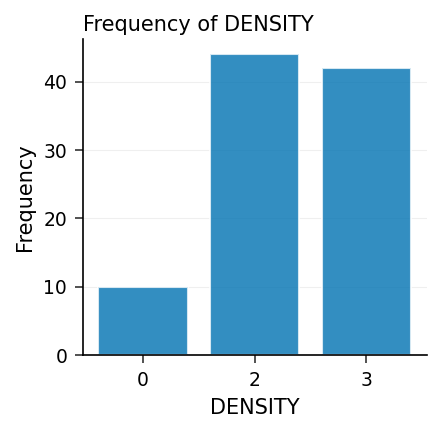

In [2]:
ΔΙΑΔΙΚΑΣΙΑ GREDUCE ΔΕΔΟΜΕΝΑ=zonemap out=reducedmap;
    id zone;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ reducedmap;
    ΟΡΙΣΜΟΣ reducedmap;
    ΕΤΙΚΕΤΑ zone="Ζώνη" x="Συντεταγμένη X" y="Συντεταγμένη Y" DENSITY="Επίπεδο Πυκνότητας";
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=reducedmap;
    TABLES DENSITY / nocum;
    TITLE 'Σημεία ορίου που διατηρούνται σε κάθε επίπεδο DENSITY';
ΕΚΤΕΛΕΣΗ;

## Βήμα 3 — Εξέταση των επιπέδων πυκνότητας

Ο πίνακας συχνοτήτων δείχνει πώς η GREDUCE βαθμολόγησε τα 96 σημεία ορίου:

| DENSITY | Σημεία | Ποσοστό |
|---------|--------|-------|
| 0 | 10 | 10,4% |
| 2 | 44 | 45,8% |
| 3 | 42 | 43,8% |

Μόνο 10 σημεία φέρουν το χαμηλότερο επίπεδο (τα σημεία-άγκυρες βασικού σχήματος), ενώ τα υπόλοιπα 86 κατανέμονται στα επίπεδα 2 και 3. Για ένα επίπεδο πίνακα ελέγχου διατηρούμε όλα στο `DENSITY <= 2`: αυτό διατηρεί 54 από τα 96 σημεία, αφαιρώντας τις 42 κορυφές λεπτομερέστερης λεπτομέρειας (`DENSITY=3`). Η PROC MEANS παρακάτω επιβεβαιώνει ότι το χονδρό επίπεδο περιέχει 13–14 κορυφές ανά ζώνη αντί για τις αρχικές 24.

In [3]:
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=reducedmap n;
    ΚΛΑΣΗ zone;
    ΟΠΟΥ DENSITY <= 2;
    ΜΕΤΑΒΛΗΤΗ x;
    TITLE 'Κορυφές που διατηρούνται ανά ζώνη στη λεπτομέρεια πίνακα ελέγχου (DENSITY <= 2)';
ΕΚΤΕΛΕΣΗ;

                    Κορυφές που διατηρούνται ανά ζώνη στη λεπτομέρεια πίνακα ελέγχου (DENSITY <= 2)                     

                                                  The MEANS Procedure

                                    Analysis Variable : x Συντεταγμένη X

        Ζώνη              N Obs
        -----------------------
        1                    14
        2                    13
        3                    14
        4                    13
        -----------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Βήμα 4 — Δημιουργία του χονδρού χάρτη και της απόκρισης απόδοσης ανά ζώνη

Υλοποιούμε το επίπεδο πίνακα ελέγχου ως `coarsemap` (`DENSITY <= 2`) ώστε η PROC GMAP να μπορεί να σχεδιάσει απευθείας το μειωμένο περίγραμμα. Επίσης συνθέτουμε μία γραμμή KPI ανά ζώνη — ένα **ποσοστό έγκαιρης παράδοσης** και έναν **ημερήσιο όγκο δεμάτων** — με κλειδί το `zone` ώστε η GMAP να μπορεί να χρωματίσει κάθε περιοχή.

In [4]:
ΔΕΔΟΜΕΝΑ coarsemap;
    ΟΡΙΣΜΟΣ reducedmap;
    ΟΠΟΥ DENSITY <= 2;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ zonekpi;
    CALL streaminit(771);
    ΕΠΑΝΑΛΗΨΗ zone = 1 ΕΩΣ 4;
        /* on-time rate centered near 92%, realistic spread */
        ontime_rate = round(88 + 8 * rand('beta', 5, 2), 0.1);
        parcels     = round(2000 + 6000 * rand('uniform'));
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΕΤΙΚΕΤΑ zone="Ζώνη" ontime_rate="Ποσοστό Έγκαιρης Παράδοσης (%)" parcels="Δέματα (Ημερησίως)";
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=zonekpi noobs ΕΤΙΚΕΤΑ;
    TITLE 'Συνθετικά KPI Παράδοσης ανά Ζώνη';
ΕΚΤΕΛΕΣΗ;

                                            Συνθετικά KPI Παράδοσης ανά Ζώνη                                            

    Ζώνη                          Ποσοστό Έγκαιρης Παράδοσης (%)                 Δέματα (Ημερησίως)
       1                                                    92.6                               4704
       2                                                    95.6                               2932
       3                                                    93.4                               2934
       4                                                    94.6                               2516




NOTE: DATA coarsemap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote coarsemap (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA zonekpi


NOTE: Wrote zonekpi (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=zonekpi

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


Τα τέσσερα συνθετικά ποσοστά έγκαιρης παράδοσης κυμαίνονται μεταξύ 92,6% και 95,6%, με ημερήσιους όγκους δεμάτων από περίπου 2.500 έως 4.700. Η ζώνη 2 είναι η ισχυρότερη επίδοση με 95,6%· η ζώνη 1 είναι η ασθενέστερη με 92,6%. Αυτές είναι οι τιμές που κωδικοποιούν οι έγχρωμες ζώνες του χωροθεματικού χάρτη.

## Βήμα 5 — Απόδοση χωροθεματικών χαρτών πλήρους έναντι μειωμένης λεπτομέρειας

Σχεδιάζουμε τον ίδιο χωροθεματικό χάρτη έγκαιρης παράδοσης δύο φορές: μία από το πλήρες σύνολο δεδομένων 96 κορυφών `reducedmap` και μία από το σύνολο δεδομένων 54 κορυφών `coarsemap`. Η `MAP=` παρέχει τα όρια, η `DATA=` την απόκριση KPI, και οι δύο μοιράζονται το ίδιο ID `zone`. Η δήλωση `CHORO` γεμίζει κάθε ζώνη με βάση το `ontime_rate` με `LEVELS=4` έγχρωμες ζώνες και `COUTLINE=` για ευκρινή περιγράμματα. Η σύγκριση των δύο χαρτών δείχνει τι κοστίζει η μείωση οπτικά.

                                          Πλήρης λεπτομέρεια: 96 κορυφές ορίου                                          




NOTE: Option TITLE changed to Πλήρης λεπτομέρεια: 96 κορυφές ορίου.
NOTE: PROC GMAP map=reducedmap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Ποσοστό Έγκαιρης Παράδοσης (%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.42 seconds
  cpu   0.42 seconds


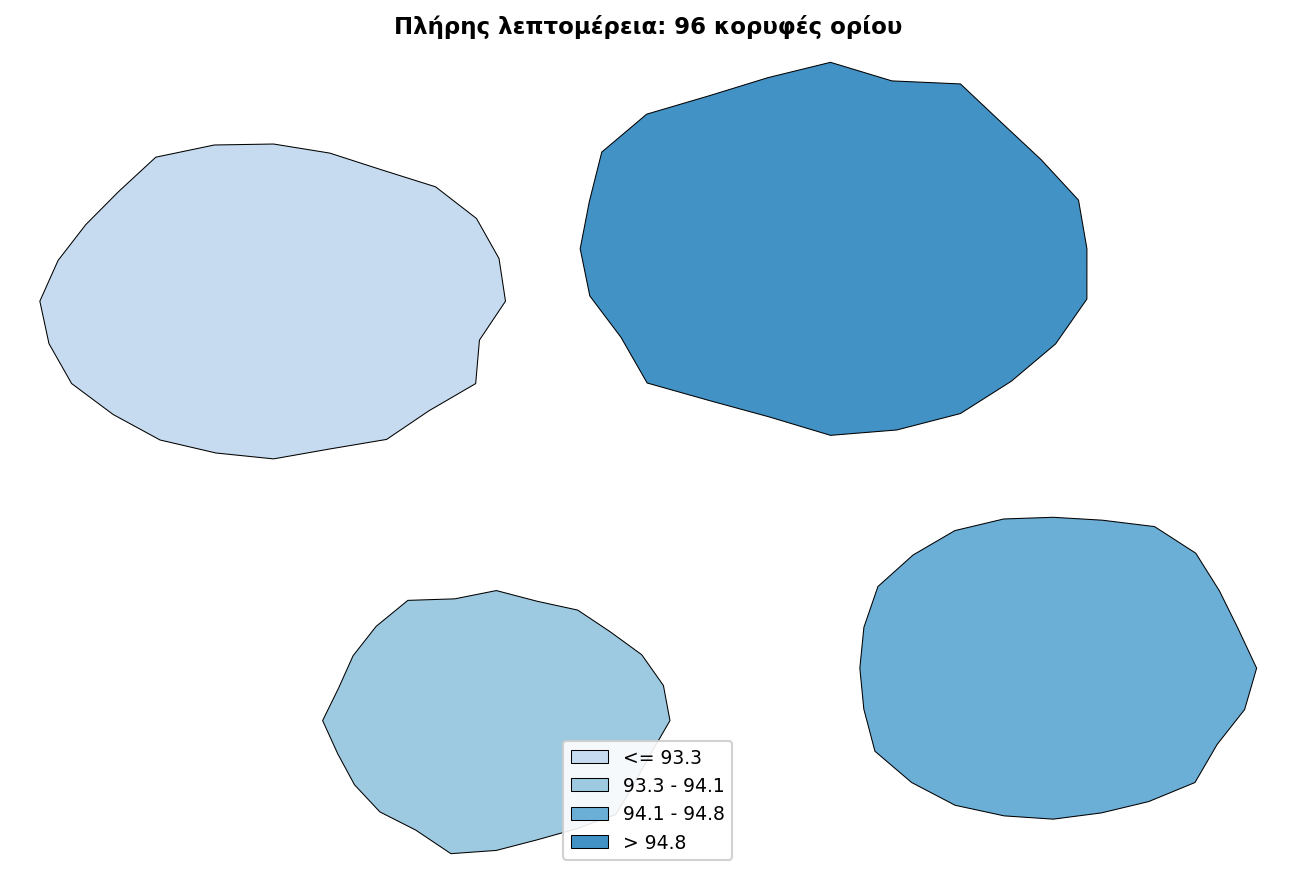

In [5]:
TITLE 'Πλήρης λεπτομέρεια: 96 κορυφές ορίου';
ΔΙΑΔΙΚΑΣΙΑ GMAP map=reducedmap ΔΕΔΟΜΕΝΑ=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black;
ΕΚΤΕΛΕΣΗ;

                                    Μειωμένη λεπτομέρεια: 54 κορυφές (DENSITY <= 2)                                     




NOTE: Option TITLE changed to Μειωμένη λεπτομέρεια: 54 κορυφές (DENSITY <= 2).
NOTE: PROC GMAP map=coarsemap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Ποσοστό Έγκαιρης Παράδοσης (%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.42 seconds
  cpu   0.42 seconds


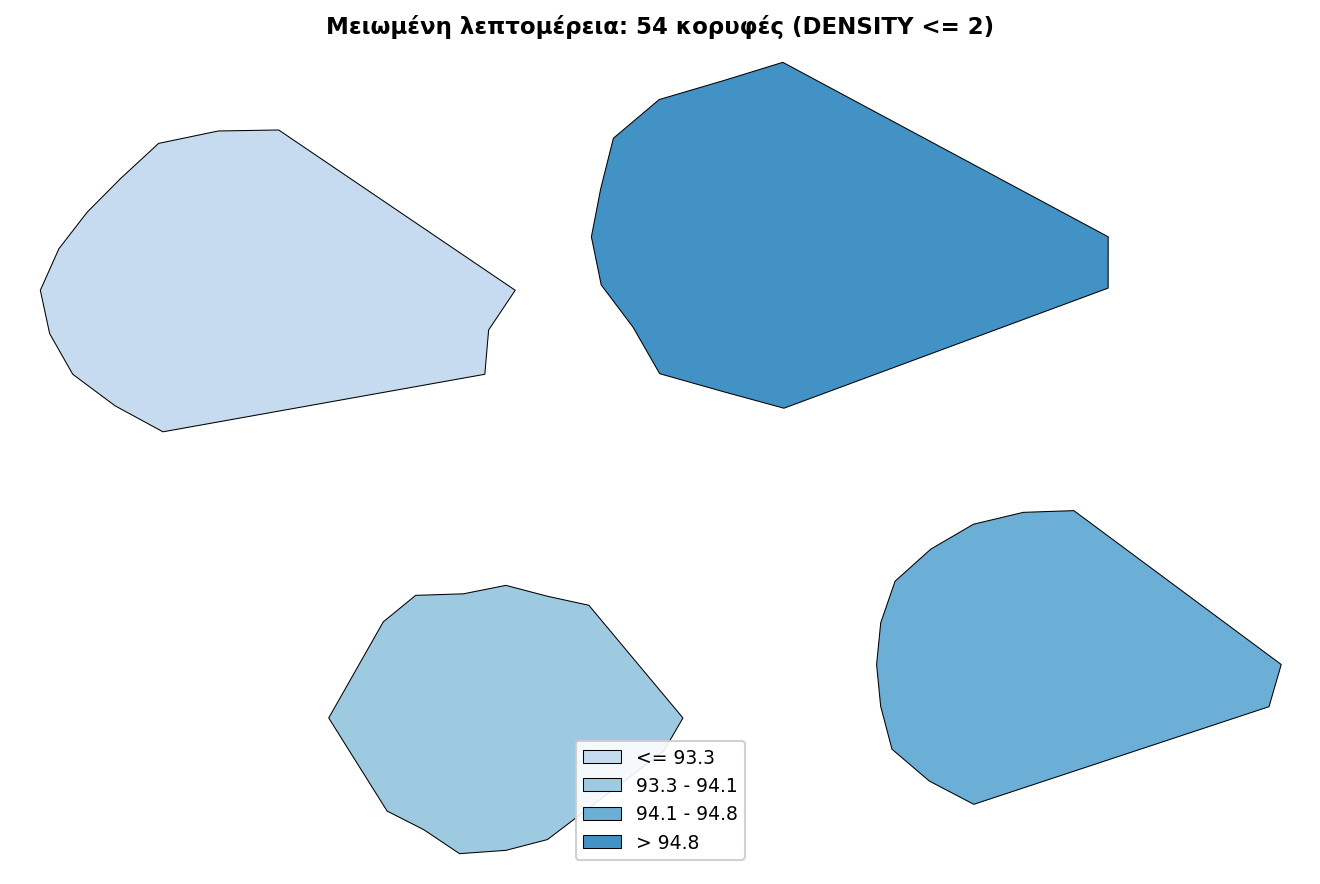

In [6]:
TITLE 'Μειωμένη λεπτομέρεια: 54 κορυφές (DENSITY <= 2)';
ΔΙΑΔΙΚΑΣΙΑ GMAP map=coarsemap ΔΕΔΟΜΕΝΑ=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black;
ΕΚΤΕΛΕΣΗ;

## Ερμηνεία των αποτελεσμάτων

Η PROC GREDUCE μετέτρεψε κάθε περίγραμμα ζώνης 24 κορυφών σε ένα διαβαθμισμένο σύνολο σημείων ορίου (επίπεδα 0, 2, και 3 σε αυτή την εκτέλεση). Η επιλογή του επιπέδου `DENSITY <= 2` μείωσε τον χάρτη από 96 κορυφές σε 54 — μια μείωση 44% στα σημεία που πρέπει να σχεδιάσει η μηχανή απόδοσης — ωστόσο οι παράπλευροι χωροθεματικοί χάρτες επιβεβαιώνουν ότι οι τέσσερις ζώνες παραμένουν σαφώς αναγνωρίσιμες: τα περιγράμματα του μειωμένου χάρτη είναι ορατά πιο γωνιώδη, αλλά κάθε περιοχή διατηρεί τη θέση, το μέγεθος και την έγχρωμη ζώνη της, οπότε ένας διαχειριστής διαβάζει την ίδια βαθμολογία και στις δύο περιπτώσεις.

Αυτή η βαθμολογία κατατάσσει τις ζώνες κατά ποσοστό έγκαιρης παράδοσης: η ζώνη 2 προηγείται με 95,6% (πιο σκούρα ζώνη), οι ζώνες 3 και 4 βρίσκονται στη μέση γύρω στο 93–95%, και η ζώνη 1 υστερεί με 92,6% (πιο ανοιχτόχρωμη ζώνη) — η περιοχή που θα διερευνούσε πρώτα ένας σχεδιαστής για ζητήματα δρομολόγησης ή χωρητικότητας καταστήματος.

Επειδή η μείωση δεν είναι καταστροφική — τα σημεία πλήρους λεπτομέρειας εξακολουθούν να υπάρχουν στο `reducedmap` — το ίδιο σύνολο δεδομένων υποστηρίζει τόσο τη γρήγορη προβολή πίνακα ελέγχου (`DENSITY <= 2`) όσο και μια προβολή εκτύπωσης ή ελέγχου υψηλής ανάλυσης (`DENSITY <= 3`, ή το πλήρες σύνολο) αλλάζοντας ένα μόνο κατώφλι `WHERE`, χωρίς ανάγκη επανεισαγωγής ή επανα-μείωσης της γεωμετρίας.